In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Helper functions
def stoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', ''))

def montoint(col):
    return pd.to_numeric(df_op[col].str.replace(',', '').str.replace('$', '', regex = False))

def pertoint(col): # converts to float, keeping as int for now because it's similar name structure
    return pd.to_numeric(df_op[col].str.replace('%', '')) / 100

In [3]:
df = pd.read_csv('Medicare_Part_D_Prescribers_by_Provider_2023.csv', low_memory = False)

In [4]:
df.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name',
       'Prscrbr_MI', 'Prscrbr_Crdntls', 'Prscrbr_Ent_Cd', 'Prscrbr_St1',
       'Prscrbr_St2', 'Prscrbr_City', 'Prscrbr_State_Abrvtn',
       'Prscrbr_State_FIPS', 'Prscrbr_zip5', 'Prscrbr_RUCA',
       'Prscrbr_RUCA_Desc', 'Prscrbr_Cntry', 'Prscrbr_Type',
       'Prscrbr_Type_src', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Drug_Cst',
       'Tot_Day_Suply', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms',
       'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply',
       'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes', 'Brnd_Sprsn_Flag',
       'Brnd_Tot_Clms', 'Brnd_Tot_Drug_Cst', 'Gnrc_Sprsn_Flag',
       'Gnrc_Tot_Clms', 'Gnrc_Tot_Drug_Cst', 'Othr_Sprsn_Flag',
       'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'MAPD_Sprsn_Flag',
       'MAPD_Tot_Clms', 'MAPD_Tot_Drug_Cst', 'PDP_Sprsn_Flag', 'PDP_Tot_Clms',
       'PDP_Tot_Drug_Cst', 'LIS_Sprsn_Flag', 'LIS_Tot_Clms', 'LIS_Drug_Cst',
       'NonLIS_Sprsn_Flag', 'NonLIS_T

In [5]:
df.isnull().sum()

PRSCRBR_NPI                   0
Prscrbr_Last_Org_Name         0
Prscrbr_First_Name            1
Prscrbr_MI               484940
Prscrbr_Crdntls          134724
                          ...  
Bene_Race_Natind_Cnt     398824
Bene_Race_Othr_Cnt       977684
Bene_Dual_Cnt            552063
Bene_Ndual_Cnt           552063
Bene_Avg_Risk_Scre            1
Length: 84, dtype: int64

In [6]:
threshold = 0.5
count = 0
for col in df.columns:
    percnull = df[col].isnull().sum() / len(df)
    if percnull > threshold:
        print(f"{col} Null percentage: {100 * percnull}%")
        count += 1
print(f"\nTotal columns above {100 * threshold}% nan: {count}")

Prscrbr_St2 Null percentage: 79.7134714068945%
GE65_Sprsn_Flag Null percentage: 76.22833924232162%
GE65_Bene_Sprsn_Flag Null percentage: 52.50129466597618%
Brnd_Sprsn_Flag Null percentage: 54.966773257814175%
Gnrc_Sprsn_Flag Null percentage: 97.21829698007845%
Othr_Sprsn_Flag Null percentage: 54.509819543480866%
MAPD_Sprsn_Flag Null percentage: 83.35903350921477%
PDP_Sprsn_Flag Null percentage: 83.35903350921477%
LIS_Sprsn_Flag Null percentage: 79.90113459818275%
NonLIS_Sprsn_Flag Null percentage: 79.90113459818275%
Opioid_LA_Prscrbr_Rate Null percentage: 73.67485957853643%
Antpsyct_GE65_Sprsn_Flag Null percentage: 62.157728341053044%
Antpsyct_GE65_Tot_Benes Null percentage: 64.1141044351816%
Bene_Age_LT_65_Cnt Null percentage: 55.968174756367404%
Bene_Age_65_74_Cnt Null percentage: 50.30677246109665%
Bene_Age_75_84_Cnt Null percentage: 61.400556977978006%
Bene_Age_GT_84_Cnt Null percentage: 68.9262058500795%
Bene_Race_Black_Cnt Null percentage: 57.57609557713131%
Bene_Race_Api_Cnt Nul

In [7]:
df_op = df.copy()

In [8]:
droplist = ['Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_MI', 'Prscrbr_St1', 'Prscrbr_St2',
            'Prscrbr_City', 'Prscrbr_State_FIPS', 'Prscrbr_RUCA_Desc', 'Prscrbr_Type_src', 'Othr_Sprsn_Flag',
            'Othr_Tot_Clms', 'Othr_Tot_Drug_Cst', 'Bene_Dual_Cnt', 'Bene_Ndual_Cnt', 'Bene_Avg_Risk_Scre']
df_op = df_op.drop(columns = droplist)

In [9]:
missing = df_op.isnull().sum()
for key,value in missing.iteritems():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 134724
Prscrbr_Ent_Cd , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 45
Prscrbr_RUCA , 1534
Prscrbr_Cntry , 0
Prscrbr_Type , 3
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 143405
GE65_Sprsn_Flag , 1052458
GE65_Tot_Clms , 328207
GE65_Tot_30day_Fills , 328207
GE65_Tot_Drug_Cst , 328207
GE65_Tot_Day_Suply , 328207
GE65_Bene_Sprsn_Flag , 724867
GE65_Tot_Benes , 655798
Brnd_Sprsn_Flag , 758907
Brnd_Tot_Clms , 621758
Brnd_Tot_Drug_Cst , 621758
Gnrc_Sprsn_Flag , 1342259
Gnrc_Tot_Clms , 38406
Gnrc_Tot_Drug_Cst , 38406
MAPD_Sprsn_Flag , 1150909
MAPD_Tot_Clms , 229756
MAPD_Tot_Drug_Cst , 229756
PDP_Sprsn_Flag , 1150909
PDP_Tot_Clms , 229756
PDP_Tot_Drug_Cst , 229756
LIS_Sprsn_Flag , 1103167
LIS_Tot_Clms , 277498
LIS_Drug_Cst , 277498
NonLIS_Sprsn_Flag , 1103167
NonLIS_Tot_Clms , 277498
NonLIS_Drug_Cst , 277498
Opioid_Tot_Clms , 347477
Opioid_Tot_Drug_Cst , 347477
Opioid_Tot_Suply , 347477
Opioid_Tot_Benes , 529631
Opioid_Prscrbr_R

In [10]:
#Prscbr

df_op['Prscrbr_Crdntls'] = df_op['Prscrbr_Crdntls'].fillna('Organization')

df_op['Prscrbr_zip5'] = df_op['Prscrbr_zip5'].fillna('Unknown')

df_op['Prscrbr_RUCA'] = df_op['Prscrbr_RUCA'].fillna('Unknown')

df_op['Prscrbr_Type'] = df_op['Prscrbr_Type'].fillna('Unknown')

In [13]:
#Totals

df_op['Tot_Clms'] = stoint('Tot_Clms')

df_op['Tot_30day_Fills'] = stoint('Tot_30day_Fills')

df_op['Tot_Drug_Cst'] = montoint('Tot_Drug_Cst')

df_op['Tot_Day_Suply'] = stoint('Tot_Day_Suply')

df_op['Tot_Benes'] = stoint('Tot_Benes').fillna(10)

In [14]:
#GE65
df_op['GE65_Sprsn_Flag'] = df_op['GE65_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Clms'] = stoint('GE65_Tot_Clms').fillna(10)

df_op['GE65_Tot_30day_Fills'] = stoint('GE65_Tot_30day_Fills')
df_op['GE65_Tot_30day_Fills'] = df_op['GE65_Tot_30day_Fills'].fillna(df_op['GE65_Tot_30day_Fills'].min())

df_op['GE65_Tot_Drug_Cst'] = montoint('GE65_Tot_Drug_Cst')
df_op['GE65_Tot_Drug_Cst'] = df_op['GE65_Tot_Drug_Cst'].fillna(df_op['GE65_Tot_Drug_Cst'].min())

df_op['GE65_Tot_Day_Suply'] = stoint('GE65_Tot_Day_Suply')
df_op['GE65_Tot_Day_Suply'] = df_op['GE65_Tot_Day_Suply'].fillna(df_op['GE65_Tot_Day_Suply'].min())

df_op['GE65_Bene_Sprsn_Flag'] = df_op['GE65_Bene_Sprsn_Flag'].notna().astype(int)

df_op['GE65_Tot_Benes'] = stoint('GE65_Tot_Benes')
df_op['GE65_Tot_Benes'] = df_op['GE65_Tot_Benes'].fillna(10)


In [15]:
#BRND

df_op['Brnd_Sprsn_Flag'] = df_op['Brnd_Sprsn_Flag'].notna().astype(int)

df_op['Brnd_Tot_Clms'] = stoint('Brnd_Tot_Clms')
df_op['Brnd_Tot_Clms'] = df_op['Brnd_Tot_Clms'].fillna(10)

df_op['Brnd_Tot_Drug_Cst'] = montoint('Brnd_Tot_Drug_Cst')
df_op['Brnd_Tot_Drug_Cst'] = df_op['Brnd_Tot_Drug_Cst'].fillna(df_op['Brnd_Tot_Drug_Cst'].min())

In [16]:
#GNRC

df_op['Gnrc_Sprsn_Flag'] = df_op['Gnrc_Sprsn_Flag'].notna().astype(int)

df_op['Gnrc_Tot_Clms'] = stoint('Gnrc_Tot_Clms')
df_op['Gnrc_Tot_Clms'] = df_op['Gnrc_Tot_Clms'].fillna(10)

df_op['Gnrc_Tot_Drug_Cst'] = montoint('Gnrc_Tot_Drug_Cst')
df_op['Gnrc_Tot_Drug_Cst'] = df_op['Gnrc_Tot_Drug_Cst'].fillna(df_op['Gnrc_Tot_Drug_Cst'].min())

In [17]:
#MAPD

df_op['MAPD_Sprsn_Flag'] = df_op['MAPD_Sprsn_Flag'].notna().astype(int)

df_op['MAPD_Tot_Clms'] = stoint('MAPD_Tot_Clms')
df_op['MAPD_Tot_Clms'] = df_op['MAPD_Tot_Clms'].fillna(10)

df_op['MAPD_Tot_Drug_Cst'] = montoint('MAPD_Tot_Drug_Cst')
df_op['MAPD_Tot_Drug_Cst'] = df_op['MAPD_Tot_Drug_Cst'].fillna(df_op['MAPD_Tot_Drug_Cst'].min())

In [18]:
#PDP

df_op['PDP_Sprsn_Flag'] = df_op['PDP_Sprsn_Flag'].notna().astype(int)

df_op['PDP_Tot_Clms'] = stoint('PDP_Tot_Clms')
df_op['PDP_Tot_Clms'] = df_op['PDP_Tot_Clms'].fillna(10)

df_op['PDP_Tot_Drug_Cst'] = montoint('PDP_Tot_Drug_Cst')
df_op['PDP_Tot_Drug_Cst'] = df_op['PDP_Tot_Drug_Cst'].fillna(df_op['PDP_Tot_Drug_Cst'].min())

In [19]:
#LIS

df_op['LIS_Sprsn_Flag'] = df_op['LIS_Sprsn_Flag'].notna().astype(int)

df_op['LIS_Tot_Clms'] = stoint('LIS_Tot_Clms')
df_op['LIS_Tot_Clms'] = df_op['LIS_Tot_Clms'].fillna(10)

df_op['LIS_Drug_Cst'] = montoint('LIS_Drug_Cst')
df_op['LIS_Drug_Cst'] = df_op['LIS_Drug_Cst'].fillna(df_op['LIS_Drug_Cst'].min())

In [20]:
#NonLIS

df_op['NonLIS_Sprsn_Flag'] = df_op['NonLIS_Sprsn_Flag'].notna().astype(int)

df_op['NonLIS_Tot_Clms'] = stoint('NonLIS_Tot_Clms')
df_op['NonLIS_Tot_Clms'] = df_op['NonLIS_Tot_Clms'].fillna(10)

df_op['NonLIS_Drug_Cst'] = montoint('NonLIS_Drug_Cst')
df_op['NonLIS_Drug_Cst'] = df_op['NonLIS_Drug_Cst'].fillna(df_op['NonLIS_Drug_Cst'].min())

In [21]:
#Opioid

df_op['Opioid_Tot_Clms'] = stoint('Opioid_Tot_Clms')
df_op['Opioid_Tot_Clms'] = df_op['Opioid_Tot_Clms'].fillna(10)

df_op['Opioid_Tot_Drug_Cst'] = montoint('Opioid_Tot_Drug_Cst')
df_op['Opioid_Tot_Drug_Cst'] = df_op['Opioid_Tot_Drug_Cst'].fillna(df_op['Opioid_Tot_Drug_Cst'].min())

df_op['Opioid_Tot_Suply'] = stoint('Opioid_Tot_Suply')
df_op['Opioid_Tot_Suply'] = df_op['Opioid_Tot_Suply'].fillna(df_op['Opioid_Tot_Suply'].min())

df_op['Opioid_Tot_Benes'] = stoint('Opioid_Tot_Benes')
df_op['Opioid_Tot_Benes'] = df_op['Opioid_Tot_Benes'].fillna(10)

df_op['Opioid_Prscrbr_Rate'] = pertoint('Opioid_Prscrbr_Rate')
df_op['Opioid_Prscrbr_Rate'] = df_op['Opioid_Prscrbr_Rate'].fillna(df_op['Opioid_Prscrbr_Rate'].min())

df_op['Opioid_LA_Tot_Clms'] = stoint('Opioid_LA_Tot_Clms')
df_op['Opioid_LA_Tot_Clms'] = df_op['Opioid_LA_Tot_Clms'].fillna(10)

df_op['Opioid_LA_Tot_Drug_Cst'] = montoint('Opioid_LA_Tot_Drug_Cst')
df_op['Opioid_LA_Tot_Drug_Cst'] = df_op['Opioid_LA_Tot_Drug_Cst'].fillna(df_op['Opioid_LA_Tot_Drug_Cst'].min())

df_op['Opioid_LA_Tot_Suply'] = stoint('Opioid_LA_Tot_Suply')
df_op['Opioid_LA_Tot_Suply'] = df_op['Opioid_LA_Tot_Suply'].fillna(df_op['Opioid_LA_Tot_Suply'].min())

df_op['Opioid_LA_Tot_Benes'] = stoint('Opioid_LA_Tot_Benes')
df_op['Opioid_LA_Tot_Benes'] = df_op['Opioid_LA_Tot_Benes'].fillna(10)

df_op['Opioid_LA_Prscrbr_Rate'] = pertoint('Opioid_LA_Prscrbr_Rate')
df_op['Opioid_LA_Prscrbr_Rate'] = df_op['Opioid_LA_Prscrbr_Rate'].fillna(df_op['Opioid_LA_Prscrbr_Rate'].min())


In [22]:
#Antibiotic

df_op['Antbtc_Tot_Clms'] = stoint('Antbtc_Tot_Clms')
df_op['Antbtc_Tot_Clms'] = df_op['Antbtc_Tot_Clms'].fillna(10)

df_op['Antbtc_Tot_Drug_Cst'] = montoint('Antbtc_Tot_Drug_Cst')
df_op['Antbtc_Tot_Drug_Cst'] = df_op['Antbtc_Tot_Drug_Cst'].fillna(df_op['Antbtc_Tot_Drug_Cst'].min())

df_op['Antbtc_Tot_Benes'] = stoint('Antbtc_Tot_Benes')
df_op['Antbtc_Tot_Benes'] = df_op['Antbtc_Tot_Benes'].fillna(10)

In [23]:
#Antipsychotic

df_op['Antpsyct_GE65_Sprsn_Flag'] = df_op['Antpsyct_GE65_Sprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Clms'] = stoint('Antpsyct_GE65_Tot_Clms')
df_op['Antpsyct_GE65_Tot_Clms'] = df_op['Antpsyct_GE65_Tot_Clms'].fillna(10)

df_op['Antpsyct_GE65_Tot_Drug_Cst'] = montoint('Antpsyct_GE65_Tot_Drug_Cst')
df_op['Antpsyct_GE65_Tot_Drug_Cst'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'].fillna(df_op['Antpsyct_GE65_Tot_Drug_Cst'].min())

df_op['Antpsyct_GE65_Bene_Suprsn_Flag'] = df_op['Antpsyct_GE65_Bene_Suprsn_Flag'].notna().astype(int)

df_op['Antpsyct_GE65_Tot_Benes'] = stoint('Antpsyct_GE65_Tot_Benes')
df_op['Antpsyct_GE65_Tot_Benes'] = df_op['Antpsyct_GE65_Tot_Benes'].fillna(10)


In [24]:
#Bene Age

df_op['Bene_Avg_Age'] = df_op['Bene_Avg_Age'].fillna(df_op['Bene_Avg_Age'].mode()[0])

df_op['Bene_Age_LT_65_Cnt'] = stoint('Bene_Age_LT_65_Cnt').fillna(10)

df_op['Bene_Age_GT_84_Cnt'] = stoint('Bene_Age_GT_84_Cnt').fillna(10)

df_op['Bene_Age_65_74_Cnt'] = stoint('Bene_Age_65_74_Cnt')
df_op['Bene_Age_75_84_Cnt'] = stoint('Bene_Age_75_84_Cnt')
df_op['Bene_Age_65_74_Cnt'] = df_op['Bene_Age_65_74_Cnt'].fillna(0)
df_op['Bene_Age_75_84_Cnt'] = df_op['Bene_Age_75_84_Cnt'].fillna(0)
df_op['Bene_Age_65_84_Cnt'] = df_op['Bene_Age_65_74_Cnt'] + df_op['Bene_Age_75_84_Cnt']
df_op = df_op.drop(columns = ['Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt'])

In [25]:
#Bene Sex

df_op['Bene_Feml_Cnt'] = stoint('Bene_Feml_Cnt')
df_op['Bene_Feml_Cnt'] = df_op['Bene_Feml_Cnt'].fillna(10)

df_op['Bene_Male_Cnt'] = stoint('Bene_Male_Cnt')
df_op['Bene_Male_Cnt'] = df_op['Bene_Male_Cnt'].fillna(10)

In [32]:
#Bene Race

df_op['Bene_Race_Wht_Cnt'] = stoint('Bene_Race_Wht_Cnt')
df_op['Bene_Race_Wht_Cnt'] = df_op['Bene_Race_Wht_Cnt'].fillna(10)

df_op['Bene_Race_Black_Cnt'] = stoint('Bene_Race_Black_Cnt')
df_op['Bene_Race_Black_Cnt'] = df_op['Bene_Race_Black_Cnt'].fillna(10)

df_op['Bene_Race_Api_Cnt'] = stoint('Bene_Race_Api_Cnt')
df_op['Bene_Race_Api_Cnt'] = df_op['Bene_Race_Api_Cnt'].fillna(10)

df_op['Bene_Race_Hspnc_Cnt'] = stoint('Bene_Race_Hspnc_Cnt')
df_op['Bene_Race_Hspnc_Cnt'] = df_op['Bene_Race_Hspnc_Cnt'].fillna(10)

#df_op['Bene_Race_Natind_Cnt'] = stoint('Bene_Race_Natind_Cnt') Already float
df_op['Bene_Race_Natind_Cnt'] = df_op['Bene_Race_Natind_Cnt'].fillna(10)

df_op['Bene_Race_Othr_Cnt'] = stoint('Bene_Race_Othr_Cnt')
df_op['Bene_Race_Othr_Cnt'] = df_op['Bene_Race_Othr_Cnt'].fillna(10)

In [33]:
missing = df_op.isnull().sum()
for key,value in missing.iteritems():
    print(key,",",value)

PRSCRBR_NPI , 0
Prscrbr_Crdntls , 0
Prscrbr_Ent_Cd , 0
Prscrbr_State_Abrvtn , 0
Prscrbr_zip5 , 0
Prscrbr_RUCA , 0
Prscrbr_Cntry , 0
Prscrbr_Type , 0
Tot_Clms , 0
Tot_30day_Fills , 0
Tot_Drug_Cst , 0
Tot_Day_Suply , 0
Tot_Benes , 0
GE65_Sprsn_Flag , 0
GE65_Tot_Clms , 0
GE65_Tot_30day_Fills , 0
GE65_Tot_Drug_Cst , 0
GE65_Tot_Day_Suply , 0
GE65_Bene_Sprsn_Flag , 0
GE65_Tot_Benes , 0
Brnd_Sprsn_Flag , 0
Brnd_Tot_Clms , 0
Brnd_Tot_Drug_Cst , 0
Gnrc_Sprsn_Flag , 0
Gnrc_Tot_Clms , 0
Gnrc_Tot_Drug_Cst , 0
MAPD_Sprsn_Flag , 0
MAPD_Tot_Clms , 0
MAPD_Tot_Drug_Cst , 0
PDP_Sprsn_Flag , 0
PDP_Tot_Clms , 0
PDP_Tot_Drug_Cst , 0
LIS_Sprsn_Flag , 0
LIS_Tot_Clms , 0
LIS_Drug_Cst , 0
NonLIS_Sprsn_Flag , 0
NonLIS_Tot_Clms , 0
NonLIS_Drug_Cst , 0
Opioid_Tot_Clms , 0
Opioid_Tot_Drug_Cst , 0
Opioid_Tot_Suply , 0
Opioid_Tot_Benes , 0
Opioid_Prscrbr_Rate , 0
Opioid_LA_Tot_Clms , 0
Opioid_LA_Tot_Drug_Cst , 0
Opioid_LA_Tot_Suply , 0
Opioid_LA_Tot_Benes , 0
Opioid_LA_Prscrbr_Rate , 0
Antbtc_Tot_Clms , 0
Antbtc_Tot

In [34]:
df_op.isnull().sum().sum()

0

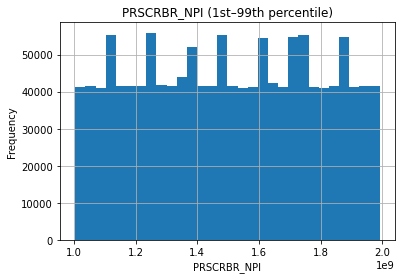

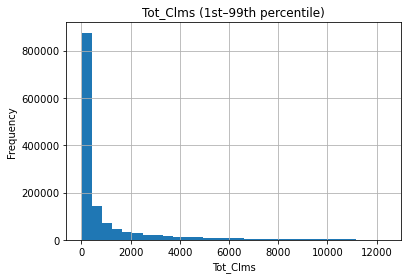

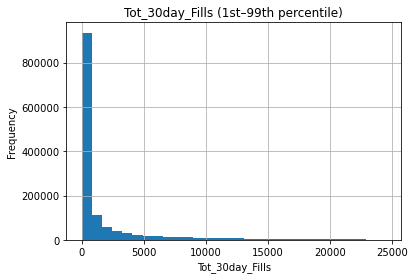

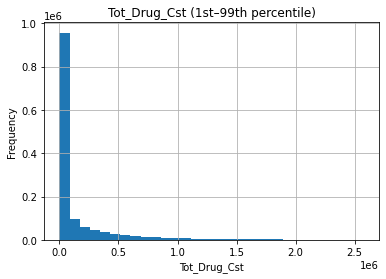

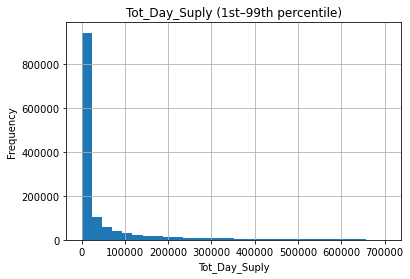

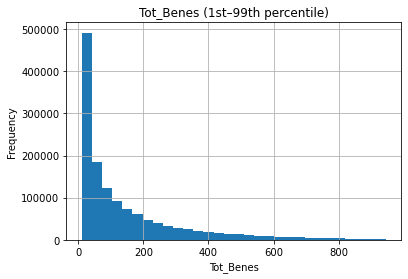

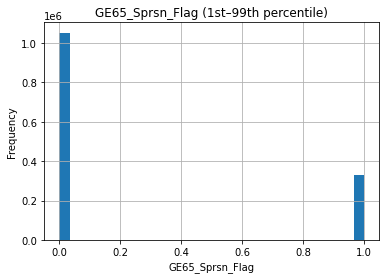

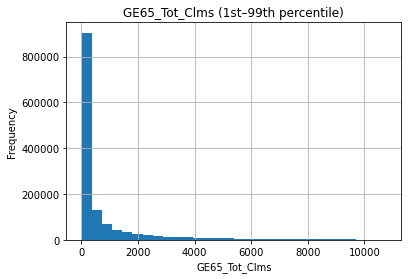

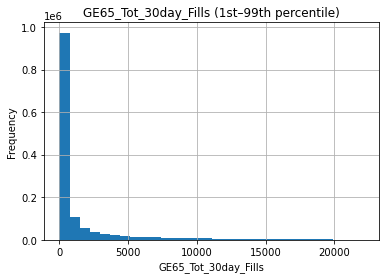

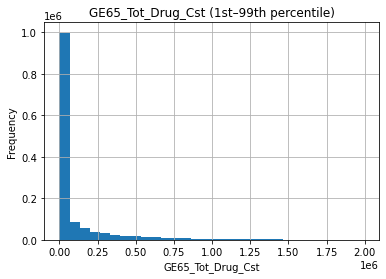

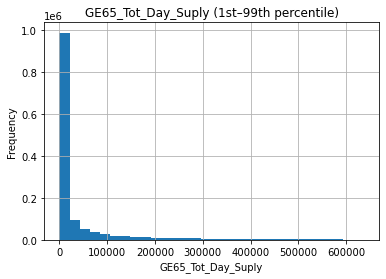

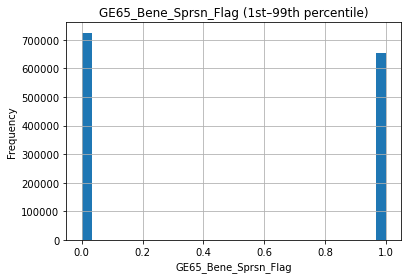

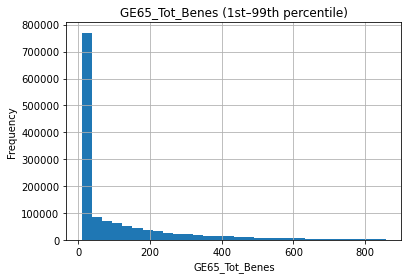

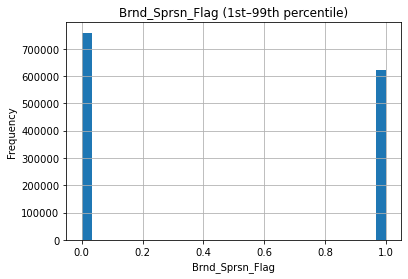

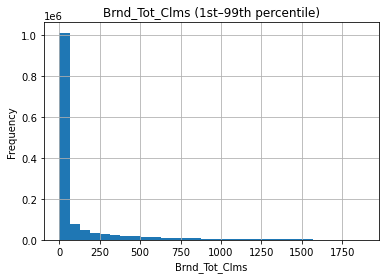

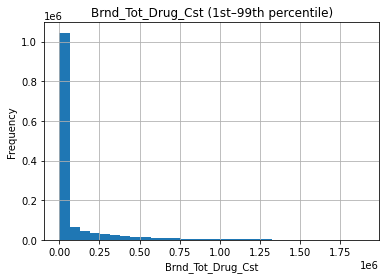

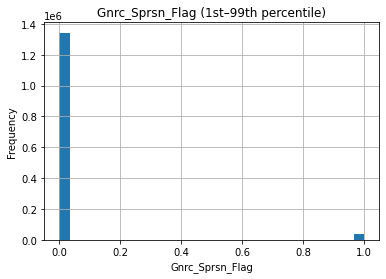

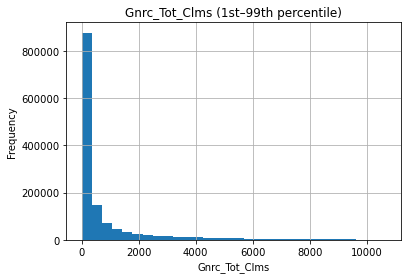

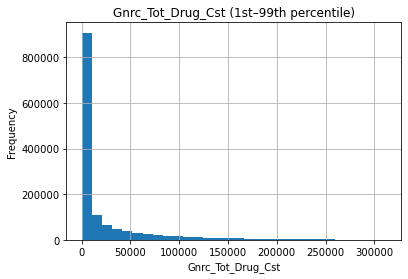

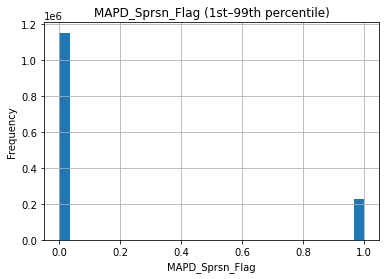

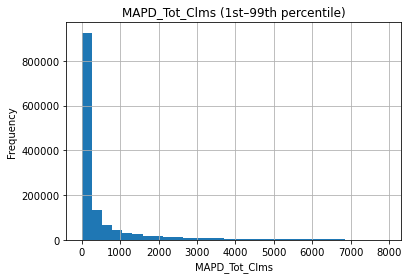

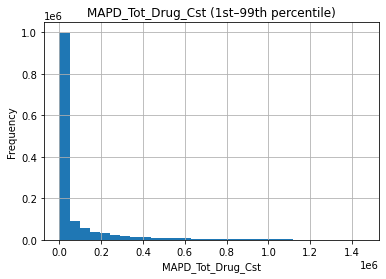

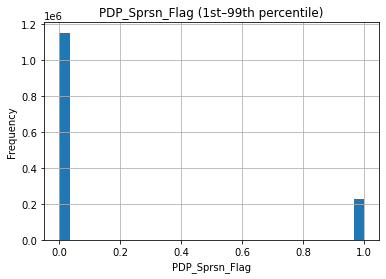

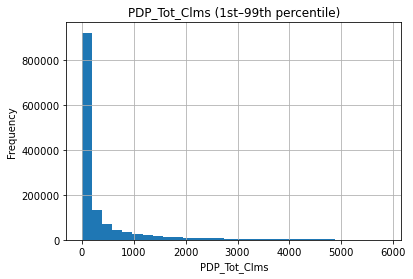

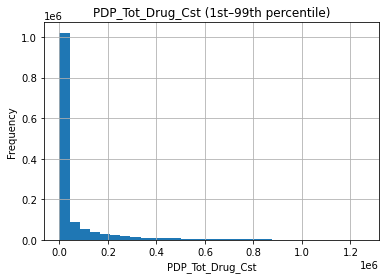

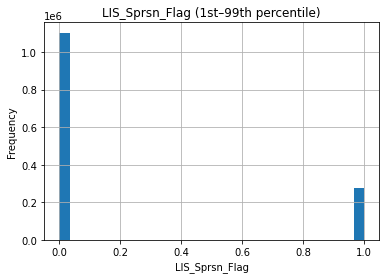

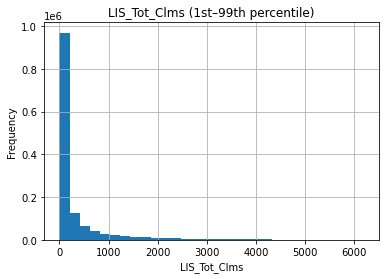

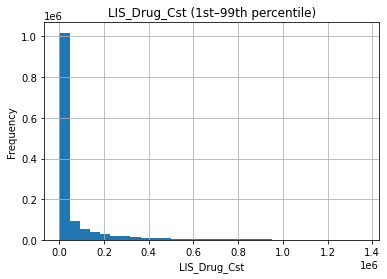

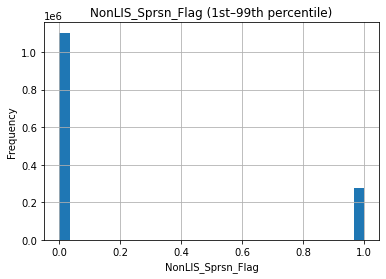

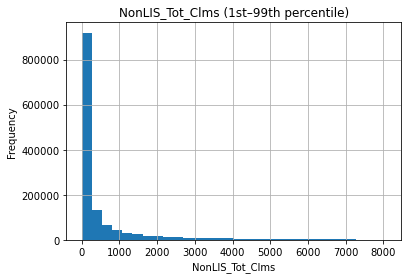

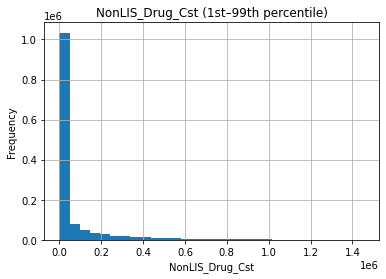

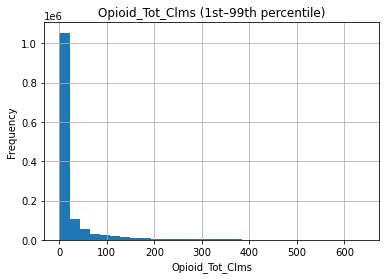

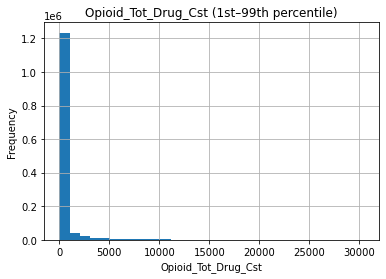

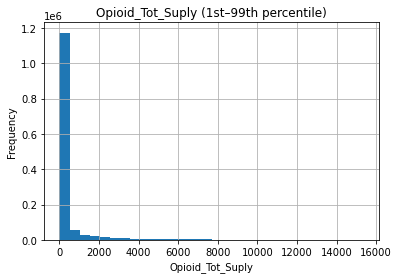

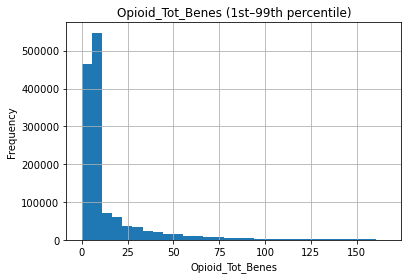

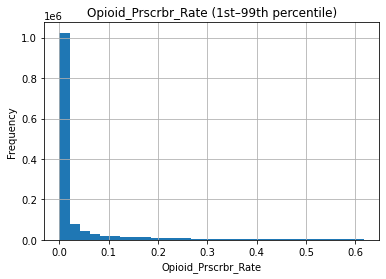

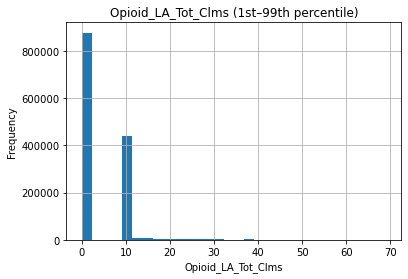

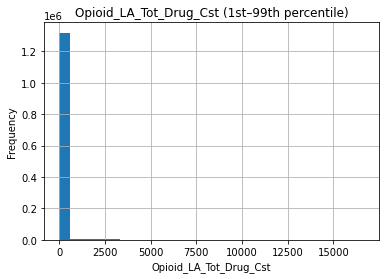

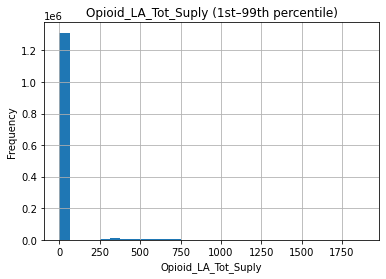

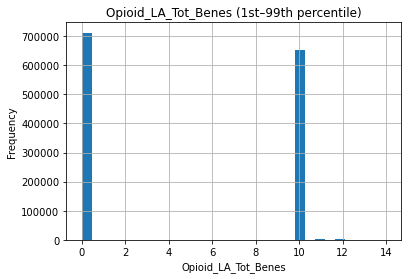

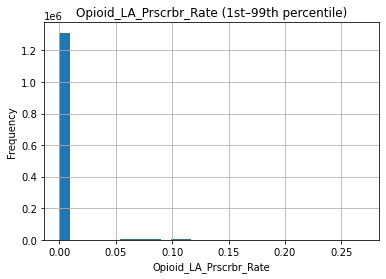

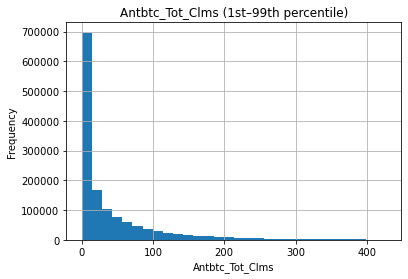

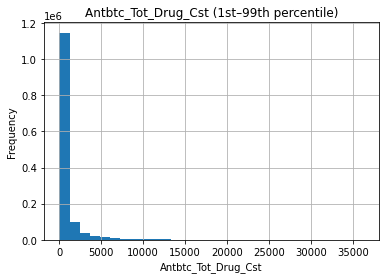

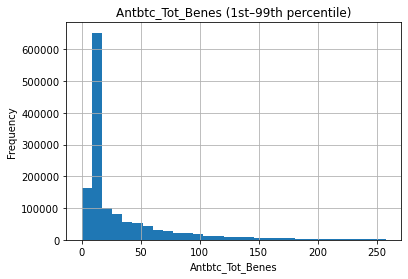

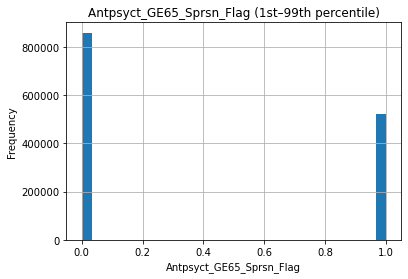

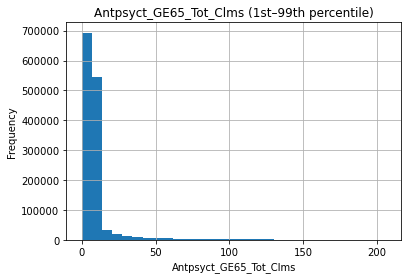

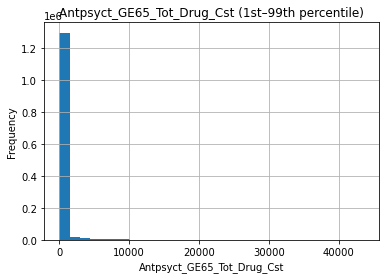

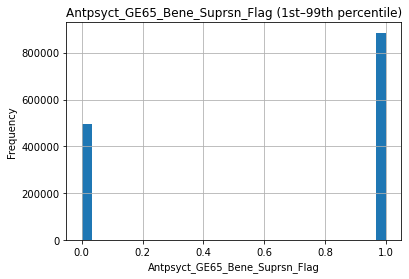

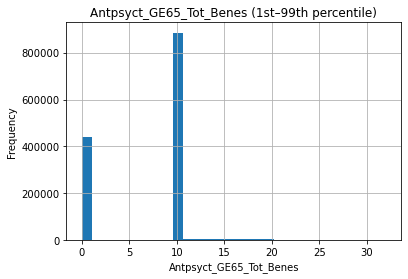

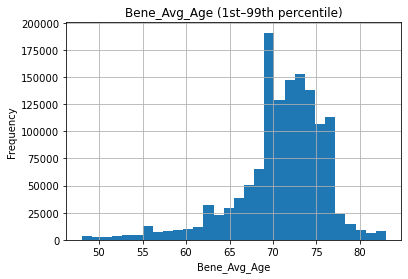

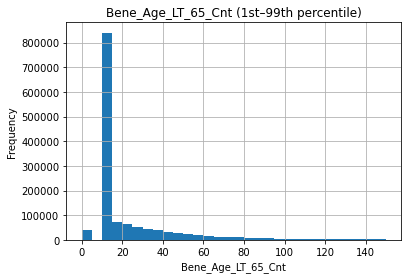

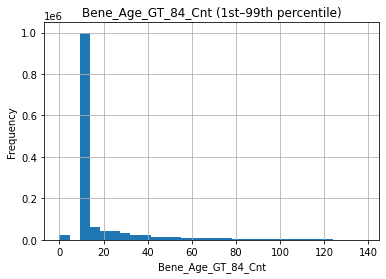

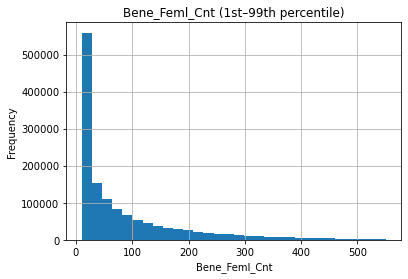

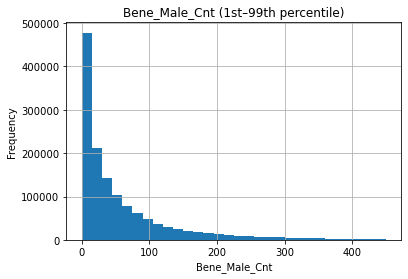

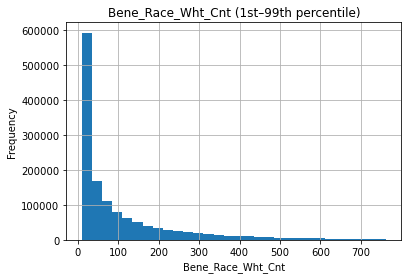

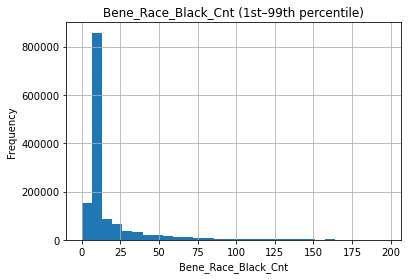

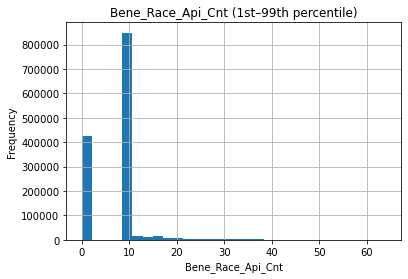

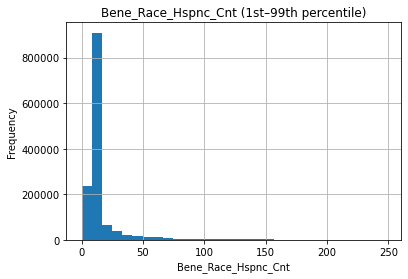

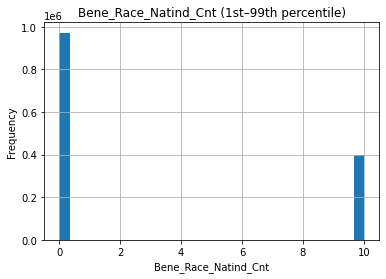

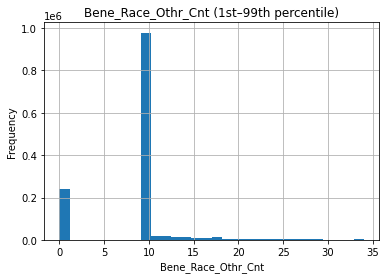

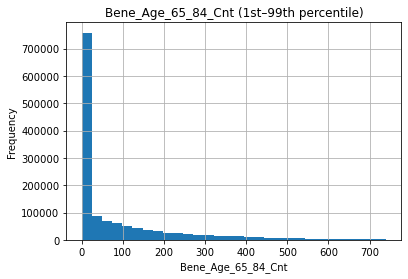

In [38]:
num_cols = df_op.select_dtypes(include='number').columns

for col in num_cols:
    lower = df_op[col].quantile(0.01)
    upper = df_op[col].quantile(0.99)
    
    df_op[col].hist(bins=30, range=(lower, upper))
    plt.title(f"{col} (1st–99th percentile)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

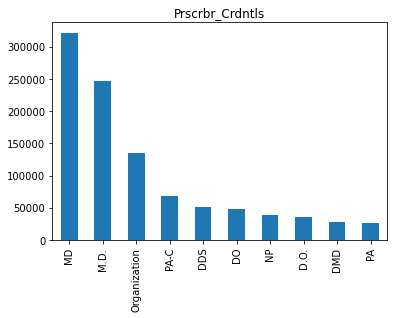

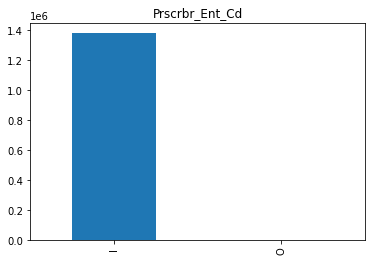

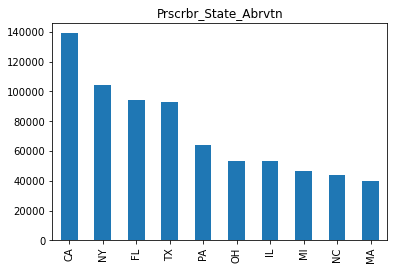

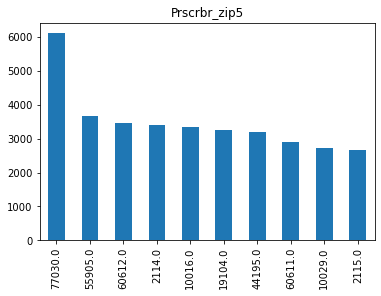

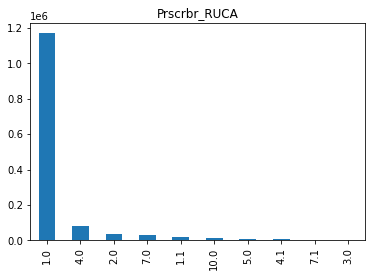

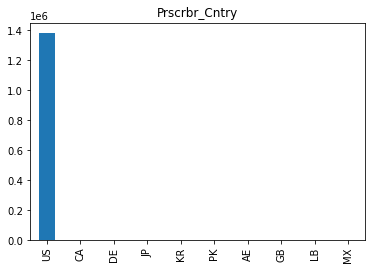

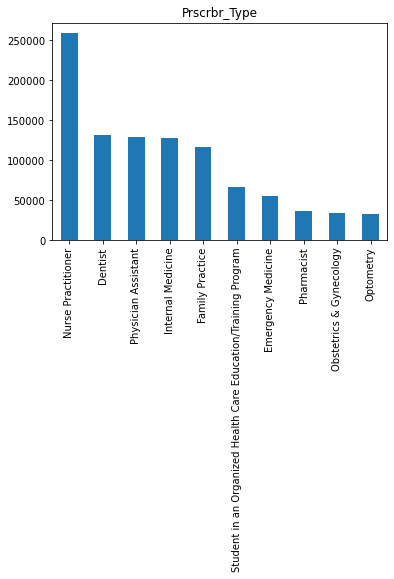

In [55]:
cat_cols = df_op.select_dtypes(include='object').columns

for col in cat_cols:
    df_op[col].value_counts().head(10).plot(kind='bar') #Change head count for more counts
    plt.title(col)
    plt.show()

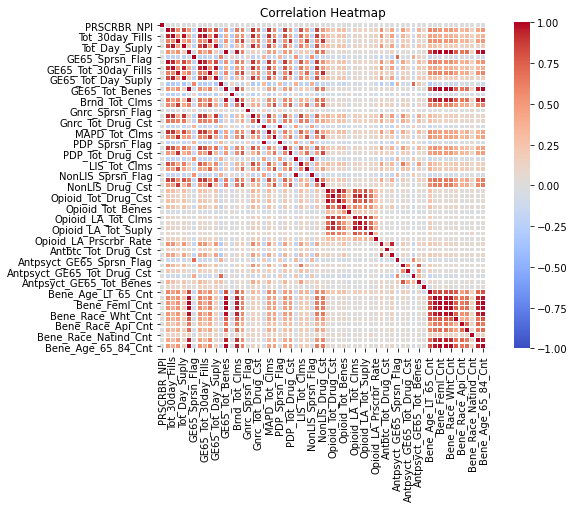

In [52]:
matrix = df_op.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    matrix,
    annot=False,       
    cmap='coolwarm',  
    vmin=-1,          
    vmax=1,
    center=0,         
    square=True,      
    linewidths=.5     
)

plt.title('Correlation Heatmap')
plt.show()

In [53]:
#Cost per patient features

df_op['Tot_Cst_Per_Bene'] = df_op['Tot_Drug_Cst'] / df_op['Tot_Benes']

df_op['GE65_Cst_Per_Bene'] = df_op['GE65_Tot_Drug_Cst'] / df_op['GE65_Tot_Benes']

df_op['Opioid_Cst_Per_Bene'] = df_op['Opioid_Tot_Drug_Cst'] / df_op['Opioid_Tot_Benes']

df_op['Opioid_LA_Cst_Per_Bene'] = df_op['Opioid_LA_Tot_Drug_Cst'] / df_op['Opioid_LA_Tot_Benes']

df_op['Antbtc_Cst_Per_Bene'] = df_op['Antbtc_Tot_Drug_Cst'] / df_op['Antbtc_Tot_Benes']

df_op['Antpsyct_GE65_Cst_Per_Bene'] = df_op['Antpsyct_GE65_Tot_Drug_Cst'] / df_op['Antpsyct_GE65_Tot_Benes']